# Synthetic Data Vault Privacy Classification Project

This project uses Synthetic Data Vault (SDV) to generate a synthetic version of the Adult Income dataset. The main goal is to test whether synthetic data can preserve useful patterns from the real dataset while reducing direct exposure to original records.

The workflow includes data exploration, synthetic data generation, synthetic data quality evaluation, machine learning model training, and comparison between models trained on real data and synthetic data.

In [1]:
# Basic data analysis libraries
import os
import warnings
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# SDV tools for synthetic data generation
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# SDMetrics reports for synthetic data evaluation
from sdmetrics.reports.single_table import DiagnosticReport, QualityReport

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Load the Adult Income Dataset

The Adult Income dataset is a real-world tabular dataset used for binary classification. The target variable shows whether a person's income is above or below 50K. This dataset is useful for this project because it contains both numerical and categorical features.

In [2]:
# Load Adult Income dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)

# Convert to a pandas DataFrame
df = adult.frame.copy()

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### 2. Clean and Prepare the Data

Before generating synthetic data, I cleaned the dataset by standardizing column names, replacing unknown values with missing values, and removing rows with missing values. This keeps the project simple and makes the workflow easier to understand.

In [3]:
# Make a copy so the original loaded data is not changed directly
clean_df = df.copy()

# Make column names easier to work with
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_")
    .str.replace(" ", "_")
)

# Replace question marks with missing values
clean_df = clean_df.replace("?", np.nan)

# Remove rows with missing values
clean_df = clean_df.dropna().reset_index(drop=True)

# The target column in this dataset is named "class"
target_col = "class"

# Clean target values by removing extra spaces
clean_df[target_col] = clean_df[target_col].astype(str).str.strip()

print("Data cleaned successfully.")
print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", clean_df.shape)

print("\nTarget class counts:")
print(clean_df[target_col].value_counts())

clean_df.head()

Data cleaned successfully.
Shape before cleaning: (48842, 15)
Shape after cleaning: (45222, 15)

Target class counts:
class
<=50K    34014
>50K     11208
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


### 3. Exploratory Data Analysis

In this section, I explore the cleaned dataset to understand the feature types, missing values, target distribution, and some basic patterns. This helps check whether the data is ready for synthetic data generation and machine learning.

In [4]:
print("Dataset shape:")
print(clean_df.shape)

print("\nColumn names:")
print(clean_df.columns.tolist())

print("\nMissing values after cleaning:")
print(clean_df.isna().sum())

print("\nData types:")
print(clean_df.dtypes)

Dataset shape:
(45222, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'class']

Missing values after cleaning:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
class             0
dtype: int64

Data types:
age                  int64
workclass         category
fnlwgt               int64
education         category
education_num        int64
marital_status    category
occupation        category
relationship      category
race              category
sex               category
capital_gain         int64
capital_loss         int64
hours_per_week       int64
native_country    category
class               o

In [5]:
print("Summary statistics for numerical columns:")
clean_df.describe()

Summary statistics for numerical columns:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


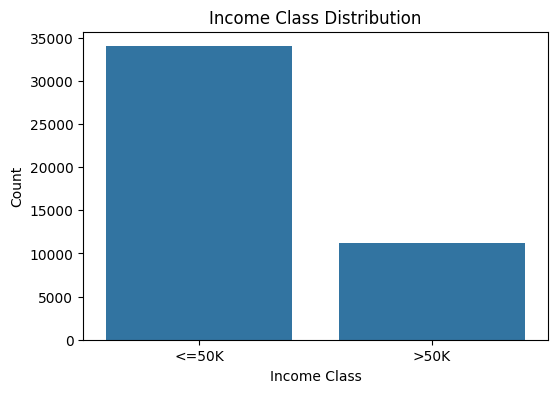

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=clean_df, x=target_col)
plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

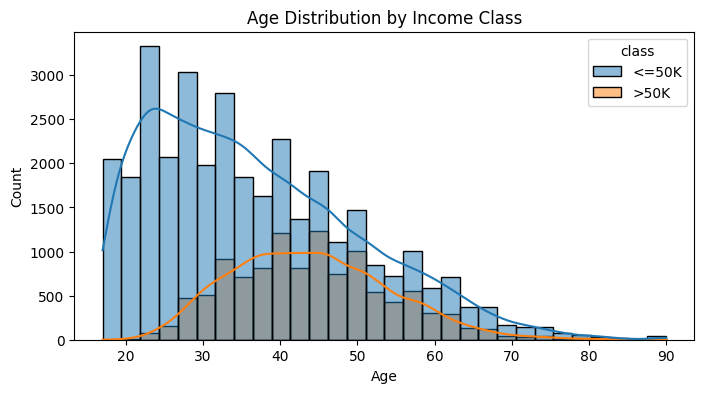

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(data=clean_df, x="age", hue=target_col, bins=30, kde=True)
plt.title("Age Distribution by Income Class")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

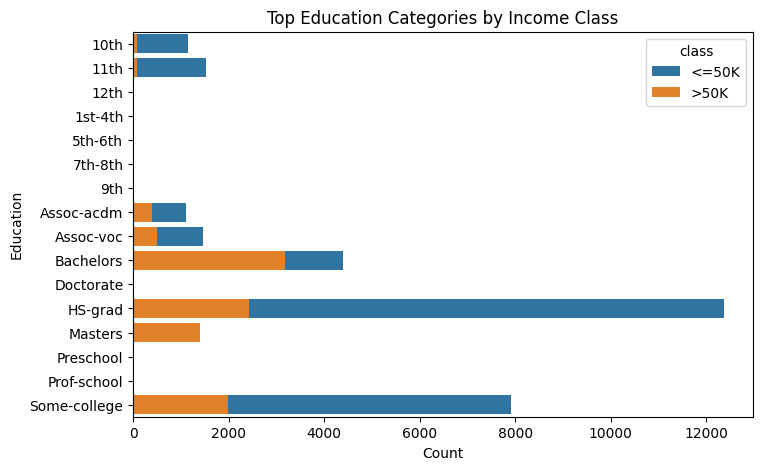

In [8]:
top_education = clean_df["education"].value_counts().head(8).index

plt.figure(figsize=(8, 5))
sns.countplot(
    data=clean_df[clean_df["education"].isin(top_education)],
    y="education",
    hue=target_col
)
plt.title("Top Education Categories by Income Class")
plt.xlabel("Count")
plt.ylabel("Education")
plt.show()

### 4. Train-Test Split

Before generating synthetic data, I split the cleaned dataset into training and testing sets. The SDV model is fitted only on the training data. The test data is kept separate and is used later to evaluate whether models trained on synthetic data can perform well on unseen real data.

In [9]:
# Split the cleaned real data into training and testing sets.
# Stratify keeps the target class ratio similar in both sets.

train_df, test_df = train_test_split(
    clean_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=clean_df[target_col]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

print("\nTraining target distribution:")
print(train_df[target_col].value_counts(normalize=True))

print("\nTesting target distribution:")
print(test_df[target_col].value_counts(normalize=True))

Training data shape: (33916, 15)
Testing data shape: (11306, 15)

Training target distribution:
class
<=50K    0.752152
>50K     0.247848
Name: proportion, dtype: float64

Testing target distribution:
class
<=50K    0.752167
>50K     0.247833
Name: proportion, dtype: float64


### 5. Build SDV Metadata

SDV needs metadata to understand the structure of the dataset. The metadata tells SDV which columns are numerical, categorical, or other data types. I use SDV's automatic metadata detection on the real training data.

In [10]:
# Create metadata object for a single-table dataset
metadata = SingleTableMetadata()

# Detect column types automatically from the training data
metadata.detect_from_dataframe(data=train_df)

print("Metadata detected successfully.")

# Show detected metadata
metadata.to_dict()

Metadata detected successfully.


{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'age': {'sdtype': 'numerical'},
  'workclass': {'sdtype': 'categorical'},
  'fnlwgt': {'sdtype': 'numerical'},
  'education': {'sdtype': 'categorical'},
  'education_num': {'sdtype': 'numerical'},
  'marital_status': {'sdtype': 'categorical'},
  'occupation': {'sdtype': 'categorical'},
  'relationship': {'sdtype': 'categorical'},
  'race': {'sdtype': 'categorical'},
  'sex': {'sdtype': 'categorical'},
  'capital_gain': {'sdtype': 'numerical'},
  'capital_loss': {'sdtype': 'numerical'},
  'hours_per_week': {'sdtype': 'numerical'},
  'native_country': {'sdtype': 'categorical'},
  'class': {'sdtype': 'categorical'}}}

### 6. Generate Synthetic Data using SDV

In this section, I use the Gaussian Copula synthesizer from SDV to learn patterns from the real training data and generate a new synthetic dataset. The synthetic dataset has the same number of rows as the real training set.

The synthesizer is fitted only on the training data, not the test data, to avoid data leakage.

In [12]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

In [13]:
# Fix categorical columns for SDV
# OpenML loads some columns as pandas "category" type.
# Converting them to normal strings prevents SDV encoding errors.

def convert_categorical_columns_to_string(dataframe):
    fixed_df = dataframe.copy()
    
    for column in fixed_df.columns:
        if str(fixed_df[column].dtype) == "category":
            fixed_df[column] = fixed_df[column].astype(str)
    
    return fixed_df


train_df = convert_categorical_columns_to_string(train_df)
test_df = convert_categorical_columns_to_string(test_df)

print("Categorical columns converted to string format.")
print(train_df.dtypes)

Categorical columns converted to string format.
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
class             object
dtype: object


In [14]:
# Initialize the SDV synthesizer
synthesizer = GaussianCopulaSynthesizer(
    metadata,
    enforce_min_max_values=True,
    enforce_rounding=True
)

print("Training the SDV synthesizer...")

# Fit the synthesizer on the real training data only
synthesizer.fit(train_df)

print("SDV synthesizer training completed.")

# Generate synthetic data with the same number of rows as the real training set
synthetic_df = synthesizer.sample(num_rows=len(train_df))

print("Synthetic data generated successfully.")
print("Synthetic data shape:", synthetic_df.shape)

synthetic_df.head()

Training the SDV synthesizer...
SDV synthesizer training completed.
Synthetic data generated successfully.
Synthetic data shape: (33916, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,47,Self-emp-not-inc,176672,11th,8,Widowed,Adm-clerical,Own-child,White,Male,1269,0,55,United-States,<=50K
1,39,Local-gov,321792,HS-grad,9,Never-married,Prof-specialty,Husband,White,Male,237,0,40,United-States,<=50K
2,30,Private,159688,HS-grad,11,Married-civ-spouse,Craft-repair,Husband,White,Female,3794,42,27,United-States,<=50K
3,24,Private,154087,Some-college,12,Married-civ-spouse,Sales,Husband,White,Male,16652,0,52,United-States,<=50K
4,32,Private,76586,Bachelors,13,Widowed,Prof-specialty,Own-child,White,Female,31379,0,30,United-States,<=50K


### 7. Evaluate Synthetic Data Quality

After generating synthetic data, I evaluated its quality using SDMetrics reports. The diagnostic report checks whether the synthetic data follows the expected structure and validity rules. The quality report compares the real and synthetic data to see how well the synthetic data captures column distributions and relationships.

In [15]:
# Convert SDV metadata into dictionary format for SDMetrics
metadata_dict = metadata.to_dict()

# Diagnostic report checks basic data validity and structure
diagnostic_report = DiagnosticReport()

diagnostic_report.generate(
    real_data=train_df,
    synthetic_data=synthetic_df,
    metadata=metadata_dict,
    verbose=True
)

diagnostic_score = diagnostic_report.get_score()

print("Diagnostic Score:", diagnostic_score)

Generating report ...

(1/2) Evaluating Data Validity: |█████████████| 15/15 [00:00<00:00, 289.96it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████████| 1/1 [00:00<00:00, 703.74it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Diagnostic Score: 1.0


In [16]:
# Quality report checks how similar the synthetic data is to the real data
quality_report = QualityReport()

quality_report.generate(
    real_data=train_df,
    synthetic_data=synthetic_df,
    metadata=metadata_dict,
    verbose=True
)

quality_score = quality_report.get_score()

print("Quality Score:", quality_score)

# Show the main quality properties
quality_report.get_properties()

Generating report ...

(1/2) Evaluating Column Shapes: |█████████████| 15/15 [00:00<00:00, 108.67it/s]|
Column Shapes Score: 90.31%

(2/2) Evaluating Column Pair Trends: |██████| 105/105 [00:00<00:00, 308.87it/s]|
Column Pair Trends Score: 75.09%

Overall Score (Average): 82.7%

Quality Score: 0.8269924224554781


,Property,Score
0,Column Shapes,0.903108
1,Column Pair Trends,0.750877


##### The synthetic data matched the individual column distributions fairly well, with a Column Shapes score of about 90%. This means SDV preserved many single-column patterns such as age distribution, work hours, and category frequencies.

##### The Column Pair Trends score was lower, around 75%, which means relationships between pairs of columns were harder to preserve. This is expected because synthetic data generation usually captures broad patterns better than complex feature interactions.

##### Overall, the quality score was about 82.7%, suggesting that the generated data is reasonably similar to the real training data, but not a perfect copy.

### 8. Prepare Data for Machine Learning

To train classification models, I separated the input features from the target column. Since the dataset contains both numerical and categorical columns, I used scaling for numerical features and one-hot encoding for categorical features.

In [17]:
# Separate features and target column

def split_features_and_target(dataframe, target_column):
    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]
    return X, y


X_train_real, y_train_real = split_features_and_target(train_df, target_col)
X_train_synthetic, y_train_synthetic = split_features_and_target(synthetic_df, target_col)
X_test, y_test = split_features_and_target(test_df, target_col)

print("Real training features shape:", X_train_real.shape)
print("Synthetic training features shape:", X_train_synthetic.shape)
print("Testing features shape:", X_test.shape)

Real training features shape: (33916, 14)
Synthetic training features shape: (33916, 14)
Testing features shape: (11306, 14)


In [18]:
# Identify categorical and numerical columns

categorical_cols = X_train_real.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X_train_real.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Numerical columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [19]:
# Preprocessing:
# - numerical columns are scaled
# - categorical columns are one-hot encoded

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


### 9. Train Classification Models

I trained two types of classifiers: Logistic Regression and Random Forest. Each model was trained once using the real training data and once using the synthetic training data. All models were evaluated on the same real test set to make the comparison fair.

In [20]:
def evaluate_classifier(model_name, training_data_name, model, X_train, y_train, X_test, y_test):
    """
    Train a classifier and evaluate it on the same real test set.
    
    Parameters:
        model_name: Name of the machine learning model.
        training_data_name: Whether the model used real or synthetic training data.
        model: Scikit-learn pipeline.
        X_train, y_train: Training features and labels.
        X_test, y_test: Real test features and labels.
    
    Returns:
        A dictionary containing evaluation scores.
    """
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    scores = {
        "model": model_name,
        "training_data": training_data_name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, pos_label=">50K"),
        "recall": recall_score(y_test, predictions, pos_label=">50K"),
        "f1_score": f1_score(y_test, predictions, pos_label=">50K")
    }

    print("=" * 70)
    print(f"{model_name} trained on {training_data_name}")
    print("=" * 70)
    print(classification_report(y_test, predictions))

    return scores

In [21]:
# Logistic Regression is a simple, interpretable baseline model
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Random Forest is added as a stronger non-linear model
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Model pipelines created successfully.")

Model pipelines created successfully.


In [22]:
results = []

# Logistic Regression trained on real data
results.append(
    evaluate_classifier(
        model_name="Logistic Regression",
        training_data_name="Real Data",
        model=logistic_model,
        X_train=X_train_real,
        y_train=y_train_real,
        X_test=X_test,
        y_test=y_test
    )
)

# Logistic Regression trained on synthetic data
results.append(
    evaluate_classifier(
        model_name="Logistic Regression",
        training_data_name="Synthetic Data",
        model=logistic_model,
        X_train=X_train_synthetic,
        y_train=y_train_synthetic,
        X_test=X_test,
        y_test=y_test
    )
)

# Random Forest trained on real data
results.append(
    evaluate_classifier(
        model_name="Random Forest",
        training_data_name="Real Data",
        model=random_forest_model,
        X_train=X_train_real,
        y_train=y_train_real,
        X_test=X_test,
        y_test=y_test
    )
)

# Random Forest trained on synthetic data
results.append(
    evaluate_classifier(
        model_name="Random Forest",
        training_data_name="Synthetic Data",
        model=random_forest_model,
        X_train=X_train_synthetic,
        y_train=y_train_synthetic,
        X_test=X_test,
        y_test=y_test
    )
)

results_df = pd.DataFrame(results)

print("Model comparison completed.")
results_df

Logistic Regression trained on Real Data
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      8504
        >50K       0.74      0.59      0.66      2802

    accuracy                           0.85     11306
   macro avg       0.81      0.76      0.78     11306
weighted avg       0.84      0.85      0.84     11306

Logistic Regression trained on Synthetic Data
              precision    recall  f1-score   support

       <=50K       0.77      0.97      0.86      8504
        >50K       0.56      0.12      0.20      2802

    accuracy                           0.76     11306
   macro avg       0.66      0.54      0.53     11306
weighted avg       0.72      0.76      0.69     11306

Random Forest trained on Real Data
              precision    recall  f1-score   support

       <=50K       0.86      0.96      0.91      8504
        >50K       0.81      0.54      0.65      2802

    accuracy                           0.85     11306
   mac

,model,training_data,accuracy,precision,recall,f1_score
0,Logistic Regression,Real Data,0.846453,0.738372,0.589222,0.655419
1,Logistic Regression,Synthetic Data,0.758181,0.555738,0.120985,0.198710
2,Random Forest,Real Data,0.853794,0.806400,0.539615,0.646568
3,Random Forest,Synthetic Data,0.752521,1.000000,0.001428,0.002851


### 10. Results Interpretation

The models trained on real data performed better than the models trained only on synthetic data. This was expected because the real training data contains the original feature relationships used for prediction.

The Logistic Regression model trained on real data achieved about 84.6% accuracy and an F1-score of about 0.66 for the `>50K` class. When trained only on synthetic data, the accuracy dropped to about 75.8%, and the F1-score for the `>50K` class dropped to about 0.20.

The Random Forest model trained on real data achieved about 85.4% accuracy, but when trained on synthetic data, it mostly predicted the majority class `<=50K`. This caused the recall and F1-score for the `>50K` class to become very low.

These results suggest that SDV preserved many broad column-level patterns, which is supported by the quality score of about 82.7%. However, the synthetic data did not fully preserve the more complex relationships needed to accurately classify the minority income group. This is also consistent with the lower Column Pair Trends score compared to the Column Shapes score.

Overall, the synthetic data was useful for demonstrating privacy-preserving data generation and basic model training, but it was not strong enough to fully replace real training data for this classification task.

In [23]:
# Save model comparison results so they are available outside the notebook
os.makedirs("../outputs", exist_ok=True)

results_path = "../outputs/model_comparison_results.csv"
results_df.to_csv(results_path, index=False)

print(f"Results saved to: {results_path}")

Results saved to: ../outputs/model_comparison_results.csv


### 13. Bonus Experiment: Simple Hyperparameter Tuning

The first model comparison showed that models trained on synthetic data had difficulty identifying the minority `>50K` class. To improve this, I added a small hyperparameter tuning experiment for Random Forest.

Instead of using a large grid search, I tested only a few practical settings. This keeps the project simple and avoids unnecessary complexity while still showing how model performance can be improved.

In [24]:
from sklearn.model_selection import GridSearchCV

# A small parameter grid to avoid long runtime
rf_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [8, 12, None],
    "classifier__min_samples_leaf": [1, 3, 5],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=rf_tuned_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest on real training data...")
grid_search.fit(X_train_real, y_train_real)

print("Best parameters for real data:")
print(grid_search.best_params_)

best_rf_real = grid_search.best_estimator_

real_tuned_results = evaluate_classifier(
    model_name="Tuned Random Forest",
    training_data_name="Real Data",
    model=best_rf_real,
    X_train=X_train_real,
    y_train=y_train_real,
    X_test=X_test,
    y_test=y_test
)

real_tuned_results

Tuning Random Forest on real training data...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for real data:
{'classifier__class_weight': None, 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Tuned Random Forest trained on Real Data
              precision    recall  f1-score   support

       <=50K       0.86      0.96      0.91      8504
        >50K       0.81      0.52      0.63      2802

    accuracy                           0.85     11306
   macro avg       0.83      0.74      0.77     11306
weighted avg       0.84      0.85      0.84     11306



{'model': 'Tuned Random Forest',
 'training_data': 'Real Data',
 'accuracy': 0.8491066690252963,
 'precision': 0.8058035714285714,
 'recall': 0.5153461812990721,
 'f1_score': 0.6286460600783631}

In [25]:
grid_search_synthetic = GridSearchCV(
    estimator=rf_tuned_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest on synthetic training data...")
grid_search_synthetic.fit(X_train_synthetic, y_train_synthetic)

print("Best parameters for synthetic data:")
print(grid_search_synthetic.best_params_)

best_rf_synthetic = grid_search_synthetic.best_estimator_

synthetic_tuned_results = evaluate_classifier(
    model_name="Tuned Random Forest",
    training_data_name="Synthetic Data",
    model=best_rf_synthetic,
    X_train=X_train_synthetic,
    y_train=y_train_synthetic,
    X_test=X_test,
    y_test=y_test
)

synthetic_tuned_results

Tuning Random Forest on synthetic training data...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for synthetic data:
{'classifier__class_weight': None, 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Tuned Random Forest trained on Synthetic Data
              precision    recall  f1-score   support

       <=50K       0.75      1.00      0.86      8504
        >50K       0.00      0.00      0.00      2802

    accuracy                           0.75     11306
   macro avg       0.38      0.50      0.43     11306
weighted avg       0.57      0.75      0.65     11306



{'model': 'Tuned Random Forest',
 'training_data': 'Synthetic Data',
 'accuracy': 0.7521669909782417,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0}

In [26]:
# Add tuned model results to the comparison table
tuned_results_df = pd.DataFrame([real_tuned_results, synthetic_tuned_results])

final_results_df = pd.concat([results_df, tuned_results_df], ignore_index=True)

final_results_df

,model,training_data,accuracy,precision,recall,f1_score
0,Logistic Regression,Real Data,0.846453,0.738372,0.589222,0.655419
1,Logistic Regression,Synthetic Data,0.758181,0.555738,0.120985,0.198710
2,Random Forest,Real Data,0.853794,0.806400,0.539615,0.646568
3,Random Forest,Synthetic Data,0.752521,1.000000,0.001428,0.002851
4,Tuned Random Forest,Real Data,0.849107,0.805804,0.515346,0.628646
5,Tuned Random Forest,Synthetic Data,0.752167,0.000000,0.000000,0.000000


In [27]:
final_results_path = "../outputs/final_model_comparison_results.csv"
final_results_df.to_csv(final_results_path, index=False)

print(f"Final tuned results saved to: {final_results_path}")

Final tuned results saved to: ../outputs/final_model_comparison_results.csv


### Hyperparameter Tuning Result

I added a small Random Forest tuning experiment to check whether model performance could improve, especially for the minority `>50K` class.

For the real-data model, tuning did not improve the F1-score compared to the original Random Forest. The original Random Forest had an F1-score of about 0.65, while the tuned version had an F1-score of about 0.63.

For the synthetic-data model, tuning did not help. The tuned synthetic Random Forest predicted only the majority `<=50K` class and completely missed the `>50K` class. This led to precision, recall, and F1-score of 0 for the positive class.

This suggests that the main limitation was not only the classifier settings. The synthetic data preserved many individual column patterns, but it did not preserve enough useful relationships for identifying the minority income group.